# Finding/opening ACCESS-CM3 `cm3-run-27-07-2026-PD-control` test run output using intake

This notebook demonstrates how to using intake-esm to find and load data data from the ACCESS-CM3 `/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control` test run.

For more information about using intake-esm to find and load data, see:
- the [intake-esm documentation](https://intake-esm.readthedocs.io/en/stable/)
- [this section](https://access-nri-intake-catalog.readthedocs.io/en/latest/usage/quickstart.html#using-an-intake-esm-datastore) of the access-nri-intake-catalog documentation

In [1]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#See the available cm3 experiment list here
#https://access-cm3-configs.readthedocs.io/Experiments/

esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json'

dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/kr4383/access-cm3-paper-figs/


In [2]:
# Parameters
esm_file = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PI-control/cm3-datastore/cm3-datastore.json"
plotfolder = "/g/data/tm70/kr4383/Notebooks/access-cm3-paper-1/notebooks/mkfigs_output4/cm3-run-27-07-2026-PI-control/"


In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import h5py
import dask.array as da
import numpy as np
import cmocean

In [4]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

http://127.0.0.1:8787/status


### Open the intake-esm datastore

In [5]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

### What ocean variables are available at monthly frequency?

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
Chl_opac,Surface chlorophyll A concentration used to fi...,,area:mean yh:mean xh:mean time: mean,mg m-3
GM_sfn_y,Parameterized Meridional Overturning Streamfun...,,rho2_i:point yq:point xh:mean time: mean,m3 s-1
KE,Layer kinetic energy per unit mass,,area:mean z_l:mean yh:mean xh:mean time: mean,m2 s-2
Kd_Itidal_Work,Work done by Internal Tide Diapycnal Mixing,,area:mean z_l:mean yh:mean xh:mean time: mean,W m-2
Kd_ePBL,ePBL diapycnal diffusivity at interfaces,,area:mean zi:point yh:mean xh:mean time: mean,m2 s-1
...,...,...,...,...
zl,"Layer pseudo-depth, -z*",,,meter
zos,Sea surface height above geoid,sea_surface_height_above_geoid,area:mean yh:mean xh:mean time: mean,m
zos_max,Sea surface height above geoid,sea_surface_height_above_geoid,area:mean yh:mean xh:mean time: max,m


### Load monthly sea surface height (`zos`) and plot the field at the last available time

In [8]:
zos = datastore.search(variable="zos", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

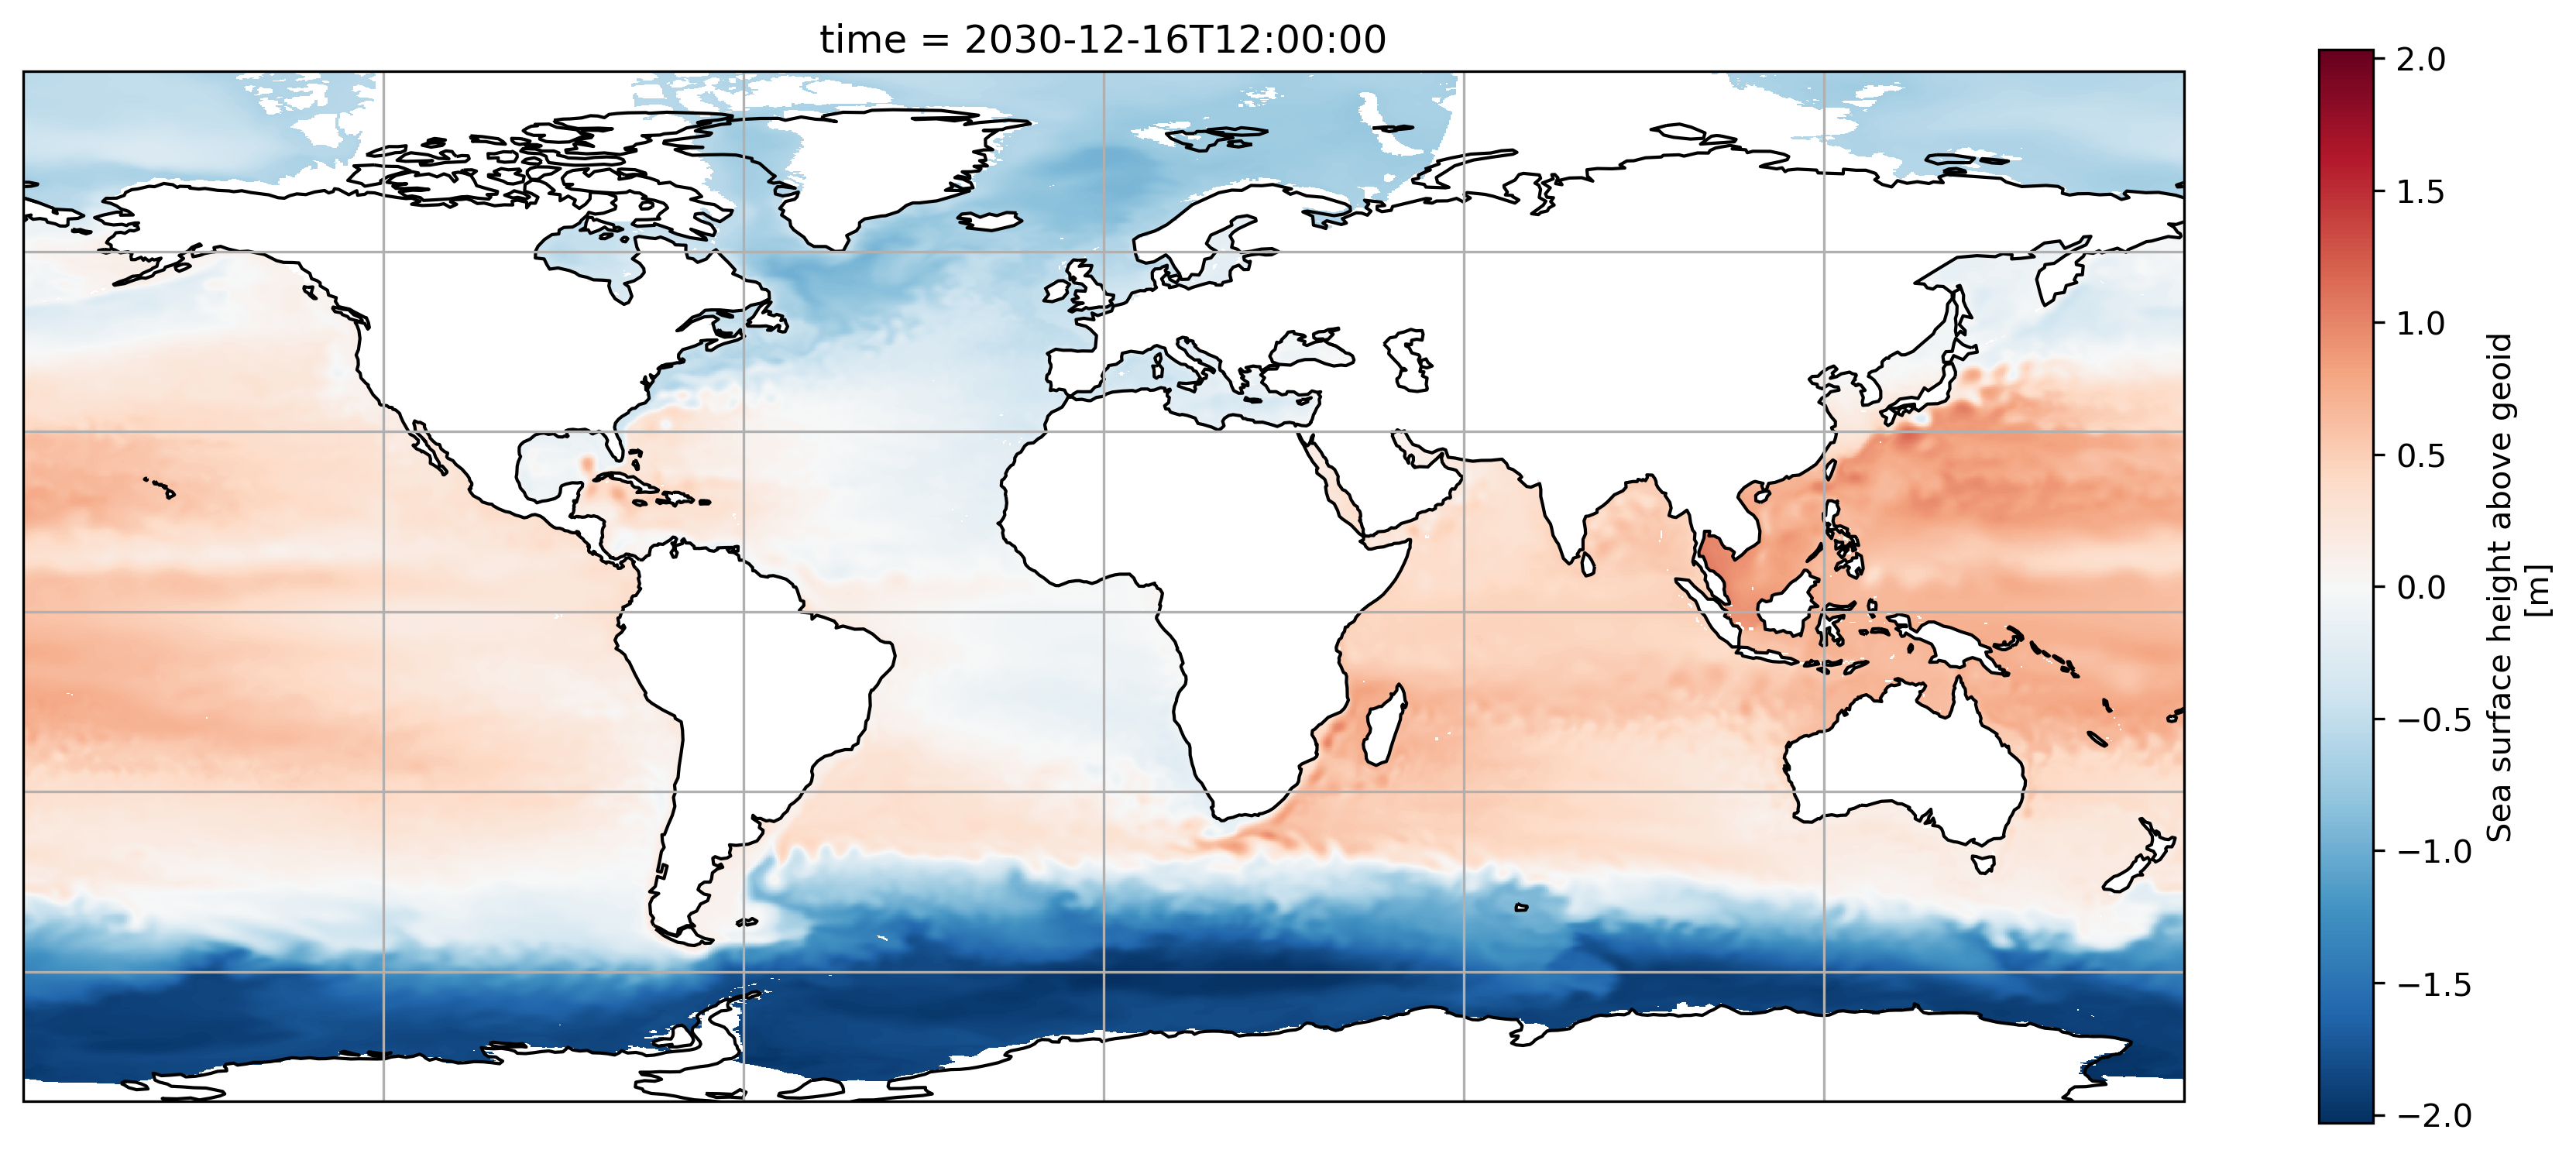

In [9]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["zos"].isel(time=-1).plot(ax=ax)
ax.coastlines()
_ = ax.gridlines()

#### Fixing the plot axes

Notice that the white land-masked regions are distorted away from the coastlines in the Arctic in the above plot. This is because a tripolar grid is used, so the grid lines are not zonal and meridional north of 65N, and consequently the nominal 1D coordinates `xh` and `yh` are incorrect. To fix this we need to use 2d coordinates `geolon` and `geolat`.

We can get these coorindates from the intake-esm datastore. However, note that `geolon` and `geolat` contain NaNs in regions where processors were masked over land. Below we replace these NaNs with zeros so that the coordinates can be used for plotting.

In [10]:
coords = datastore.search(variable=["geolat", "geolon"]).to_dask(
    preprocess=lambda ds: ds.set_coords(["geolat", "geolon"])
).reset_coords(["geolat", "geolon"]).compute()

coords = coords.fillna(0.0)

zos = zos.assign_coords(coords)

Now try that plot again, this time using `geolon` and `geolat`.

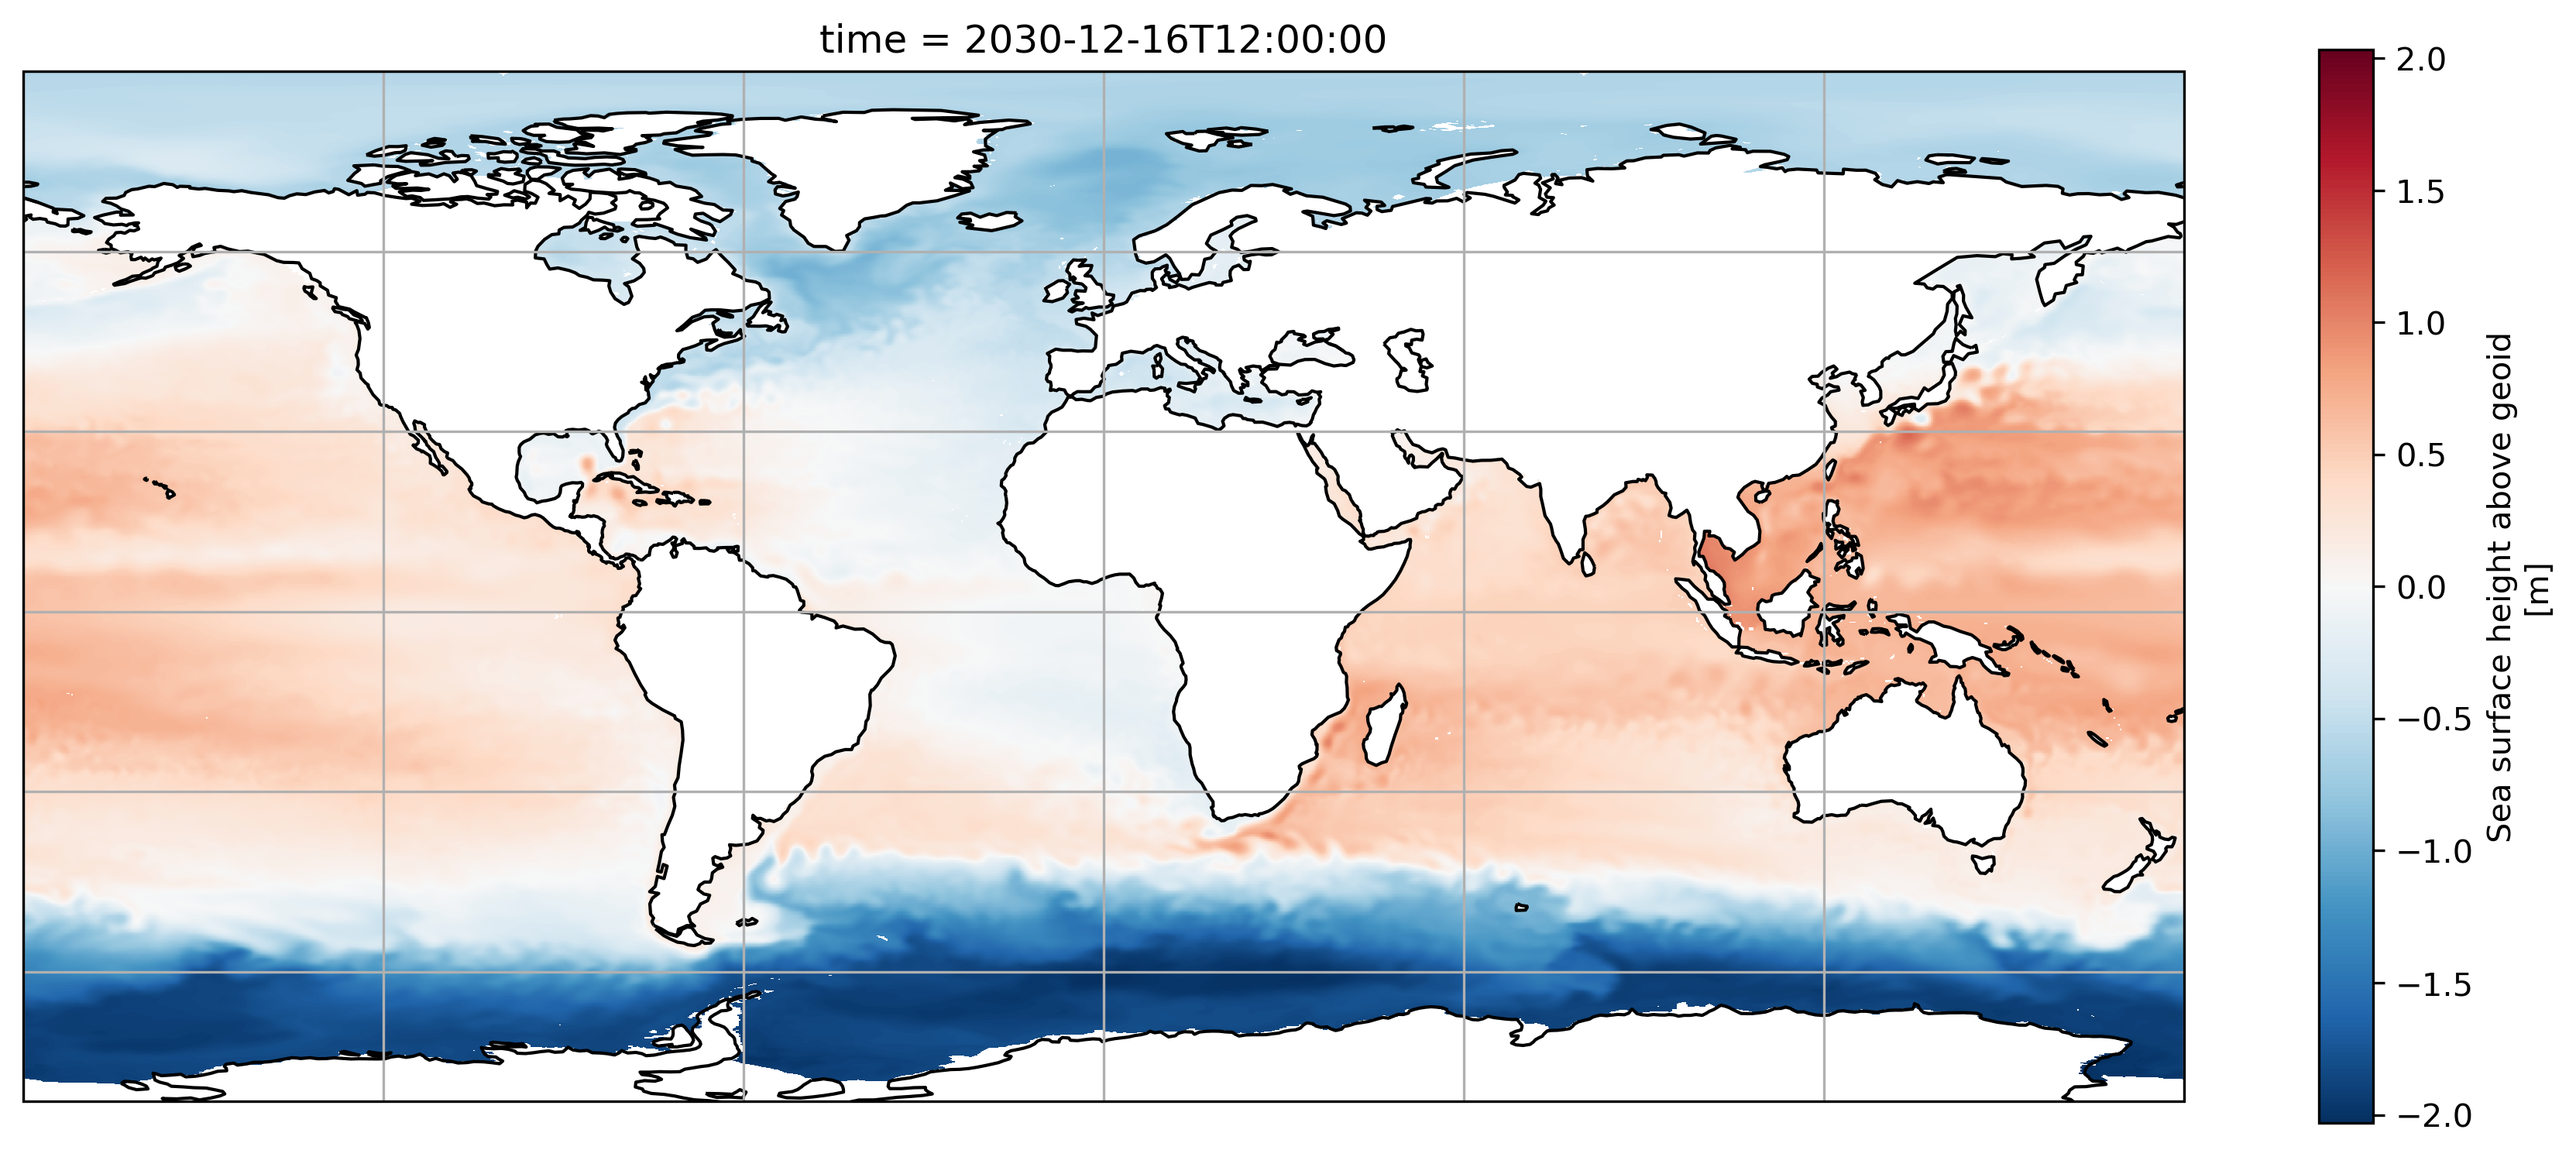

In [11]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["zos"].isel(time=-1).plot(ax=ax, x="geolon", y="geolat")

ax.coastlines()
_ = ax.gridlines()
plt.savefig(plotfolder+'exampleout.png')

## Loading atmosphere data

Atmosphere data is currently slow to load directly with the datastore. As a workaround we use the datastore to explore the available data and obtain the atmosphere data files. We then load these files with `h5py`, and manually concatenate the variables we wish to load.

In [12]:
datastore_filtered = datastore.search(realm="atmos", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
fld_s00i004,THETA AFTER TIMESTEP,air_potential_temperature,time: mean,K
fld_s00i010,SPECIFIC HUMIDITY AFTER TIMESTEP,specific_humidity,time: mean,1
fld_s00i012,QCF AFTER TIMESTEP,mass_fraction_of_cloud_ice_in_air,time: mean,kg kg-1
fld_s00i023,SNOW AMOUNT OVER LAND AFT TSTP KG/M2,surface_snow_amount,time: mean,kg m-2
fld_s00i024,SURFACE TEMPERATURE AFTER TIMESTEP,surface_temperature,time: mean,K
...,...,...,...,...
sigma_theta_2,sigma,,,1
theta_level_height,level_height,,,m
theta_level_height_0,level_height,,,m


In [13]:
atm_fps = datastore.search(variable="fld_s01i208", frequency="1mon").df.sort_values(by='start_date').path.values
atm_ds_list = [h5py.File(fp, "r") for fp in atm_fps]

In [14]:
# open one monthly dataset with xarray to get coordinates
atm_xr_ds_sample = xr.open_dataset(atm_fps[0])

In [15]:
def get_atm_data_monthly(name):
    # use monthly dataset to get dimensions
    dims = atm_xr_ds_sample[name].dims
    # concatenate data
    darr = xr.DataArray(da.concatenate([da.from_array(ds[f"/{name}"]) for ds in atm_ds_list]), dims=dims)
    
    # use monthly dataset to get spatial coordinates
    atm_coords = dict((dim, atm_xr_ds_sample[name].coords[dim].data) for dim in dims)
    # calculate time coordinates assuming monthly means
    first_month = atm_coords['time'][0].astype("datetime64[M]")
    months = first_month + np.arange(len(atm_fps))
    month_starts = months.astype("datetime64[ns]")
    next_month_starts = (months + 1).astype("datetime64[ns]")
    half_month = (next_month_starts - month_starts) // 2
    atm_coords['time'] = month_starts + half_month
    
    # assign coordinates
    darr = darr.assign_coords(atm_coords)
    return darr

In [16]:
sw_out = get_atm_data_monthly("fld_s01i208")

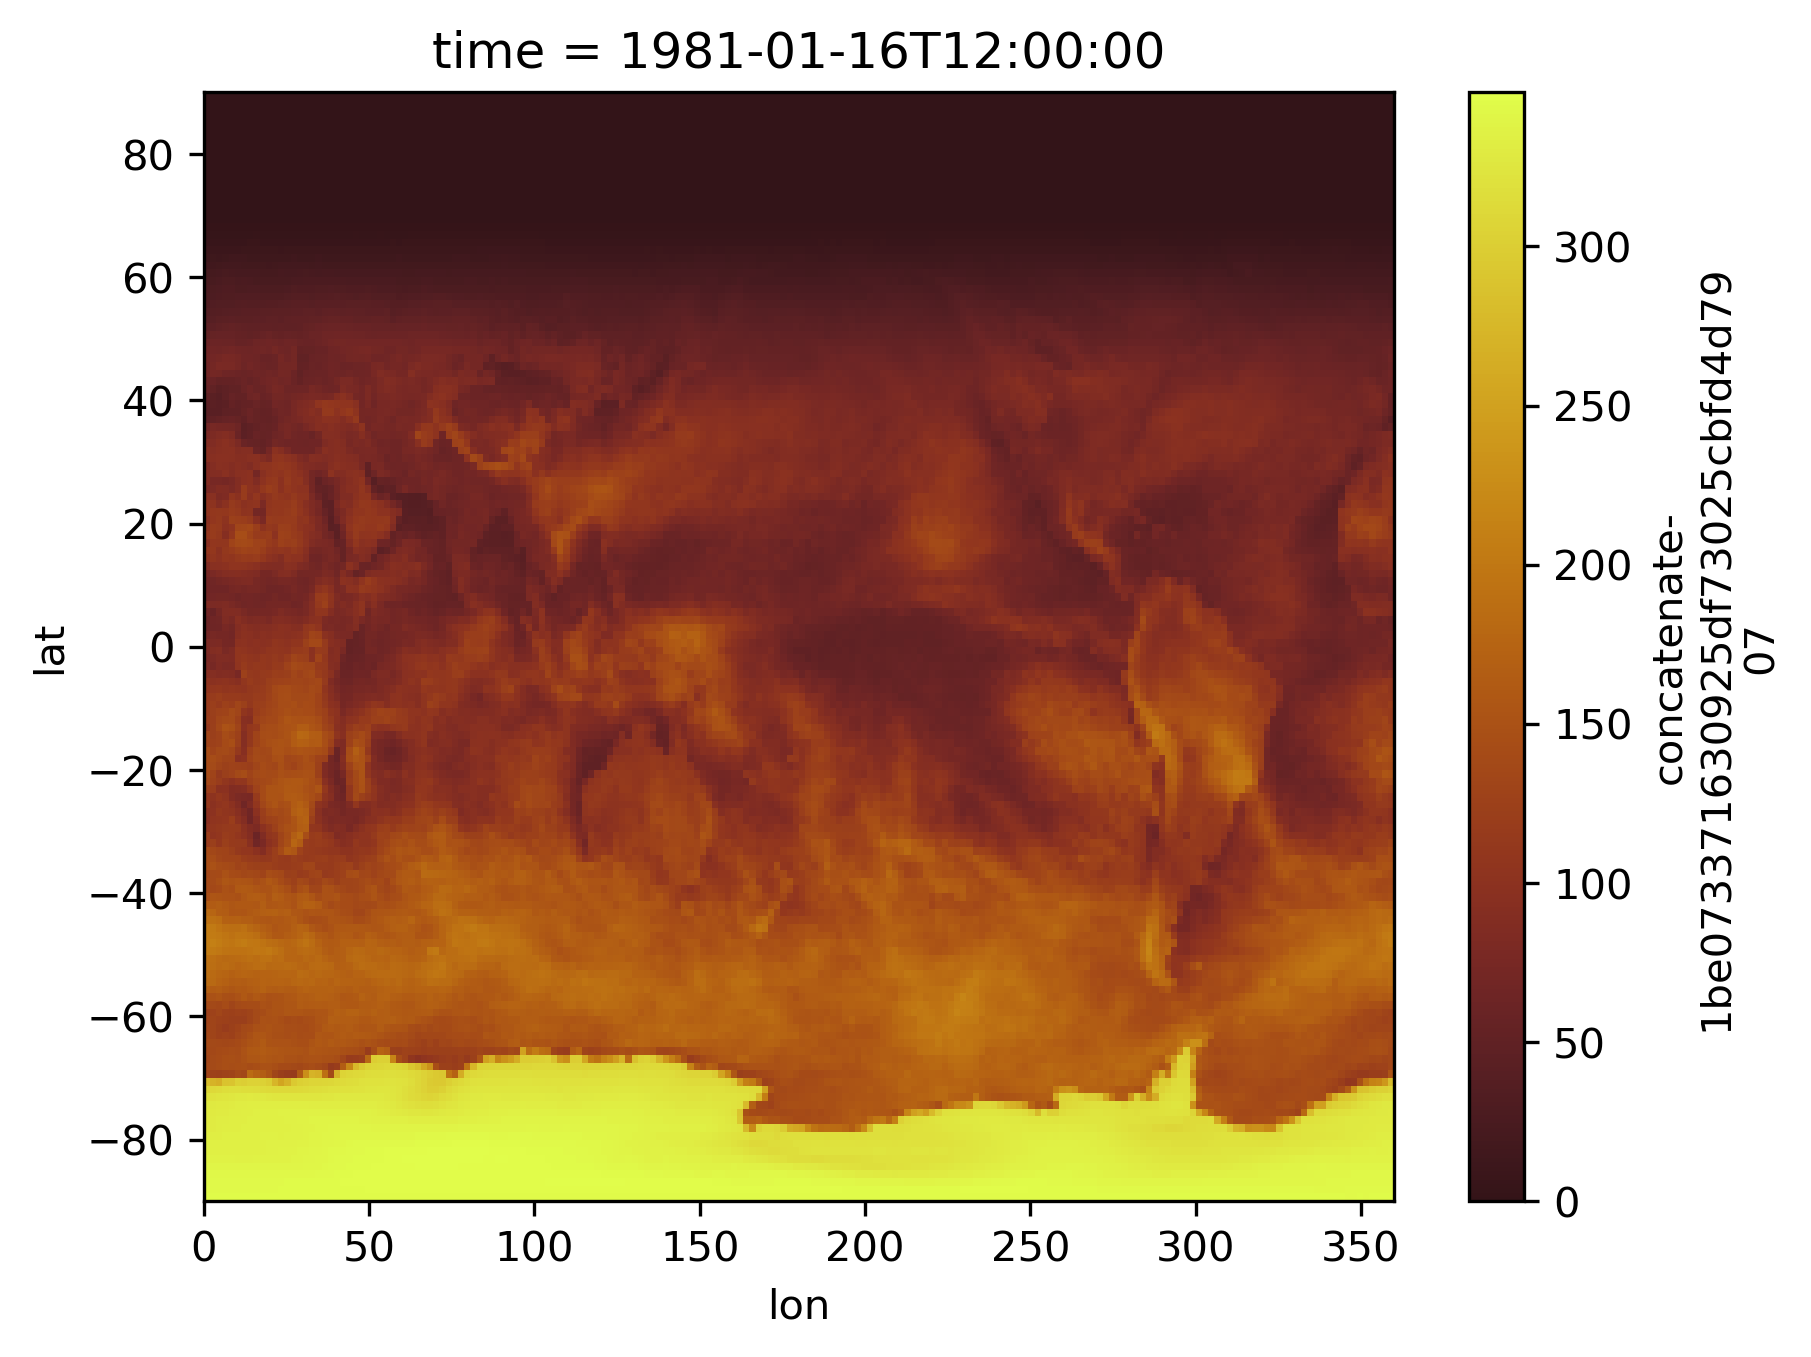

In [17]:
sw_out.isel(time=0).plot(cmap=cmocean.cm.solar)